# 02 — Single-Game Test Bench

Run every collector against one appid and inspect the outputs. Use this to:

- Sanity-check that the APIs still return what the parsers expect after a Steam/ITAD update.
- Eyeball one game end-to-end before committing to a 5,000-game pipeline run.
- Demo the data shape for the writeup (genre rows, price history, CCU curve, etc.).

Uses an **in-memory SQLite DB** — nothing here touches `data/steam.db`. Change `APPID` in the config cell and run the notebook top-to-bottom.

## Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import matplotlib.pyplot as plt

from src import db, steam_api, steamspy_api, itad_api, steamcharts
from src.utils import load_keys

keys = load_keys()
print(f".env path: {keys.get('env_path') or 'not found'}")
print(f"ITAD key loaded: {bool(keys.get('itad'))}")

# In-memory DB so this notebook never touches the real one.
conn = db.connect(':memory:')
db.init_db(conn)
print('ready (in-memory db)')

## Config — pick one game

In [ ]:
# Change me. A few interesting test cases:
#   220     Half-Life 2          — small but classic
#   440     Team Fortress 2       — F2P, large CCU history
#   730     Counter-Strike 2      — top-100
#   570     Dota 2                — F2P MOBA
#   1086940 Baldur's Gate 3       — recent premium hold
#   105600  Terraria              — long-tail indie with frequent sales
APPID = 1086940
GAME_NAME = f'appid={APPID}'

# Seed the worklist so FK-bound tables work.
db.add_to_app_list(conn, [(APPID, GAME_NAME)], source='single_search')
print(f'testing {GAME_NAME}')

testing appid=1086940


## 1. Steam Storefront — `/api/appdetails`

Fetches the master record. Shown raw first, then decomposed into `games` + `game_genres` + `game_categories`.

In [ ]:
details = steam_api.fetch_app_details(APPID, cc='ph')
assert details is not None, 'Storefront returned success=false (delisted? region-locked?)'

# Quick view of the highlights
highlights = {
    'name':            details.get('name'),
    'type':            details.get('type'),
    'is_free':         details.get('is_free'),
    'developers':      details.get('developers'),
    'publishers':      details.get('publishers'),
    'release_date':    details.get('release_date'),
    'price_overview':  details.get('price_overview'),
    'metacritic':      details.get('metacritic'),
    'platforms':       details.get('platforms'),
    'genres':          [g['description'] for g in details.get('genres', [])],
    'categories':      [c['description'] for c in details.get('categories', [])][:8],
    'achievements':    (details.get('achievements') or {}).get('total'),
}
for k, v in highlights.items():
    print(f'{k:>16}  {v}')

            name  Baldur's Gate 3
            type  game
         is_free  False
      developers  ['Larian Studios']
      publishers  ['Larian Studios']
    release_date  {'coming_soon': False, 'date': '3 Aug, 2023'}
  price_overview  {'currency': 'PHP', 'initial': 259900, 'final': 259900, 'discount_percent': 0, 'initial_formatted': '', 'final_formatted': 'P2,599.00'}
      metacritic  {'score': 96, 'url': 'https://www.metacritic.com/game/pc/baldurs-gate-3?ftag=MCD-06-10aaa1f'}
       platforms  {'windows': True, 'mac': True, 'linux': False}
          genres  ['Adventure', 'RPG', 'Strategy']
      categories  ['Single-player', 'Multi-player', 'Co-op', 'Online Co-op', 'LAN Co-op', 'Cross-Platform Multiplayer', 'Steam Achievements', 'Full controller support']
    achievements  54


In [ ]:
# Round-trip through the parser into the DB and read it back
steam_api.store_app_details(conn, APPID, details)
db.mark_progress(conn, APPID, 'has_details', 1)
GAME_NAME = details.get('name', GAME_NAME)

pd.read_sql(
    'SELECT title, type, currency, launch_price_cents, current_price_cents, '
    'discount_percent, release_date, metacritic_score, achievements_total '
    'FROM games WHERE appid = ?', conn, params=(APPID,)
).T.rename(columns={0: 'value'})

,value
title,Baldur's Gate 3
type,game
currency,PHP
launch_price_cents,259900
current_price_cents,259900
discount_percent,0
release_date,"3 Aug, 2023"
metacritic_score,96
achievements_total,54


In [ ]:
print('genres:    ', [r[0] for r in conn.execute('SELECT genre FROM game_genres WHERE appid=?', (APPID,))])
print('categories:', [r[0] for r in conn.execute('SELECT category FROM game_categories WHERE appid=?', (APPID,))])

genres:     ['Adventure', 'RPG', 'Strategy']
categories: ['Adjustable Difficulty', 'Adjustable Text Size', 'Camera Comfort', 'Co-op', 'Color Alternatives', 'Cross-Platform Multiplayer', 'Custom Volume Controls', 'Family Sharing', 'Full controller support', 'LAN Co-op', 'Multi-player', 'Online Co-op', 'Playable without Timed Input', 'Remote Play Together', 'Remote Play on TV', 'Save Anytime', 'Single-player', 'Steam Achievements', 'Steam Cloud', 'Steam Trading Cards', 'Stereo Sound', 'Subtitle Options', 'Surround Sound']


## 2. Steam reviews — `/appreviews`

Summary first, then a sample of recent individual reviews so we can see the timestamp shape.

In [ ]:
summary = steam_api.fetch_review_summary(APPID)
if summary:
    print(f'  total_reviews:     {summary.get("total_reviews"):>10,}')
    print(f'  total_positive:    {summary.get("total_positive"):>10,}')
    print(f'  total_negative:    {summary.get("total_negative"):>10,}')
    print(f'  review_score_desc: {summary.get("review_score_desc")}')
    steam_api.store_review_summary(conn, APPID, summary)
else:
    print('no review summary returned')

  total_reviews:        836,256
  total_positive:       809,584
  total_negative:        26,672
  review_score_desc: Overwhelmingly Positive


In [ ]:
# Pull 1 page of recent reviews to inspect the per-review shape
reviews = steam_api.fetch_review_timestamps(APPID, max_pages=1)
print(f'fetched {len(reviews)} reviews on the first page')
if reviews:
    df = pd.DataFrame(reviews)
    df['created'] = pd.to_datetime(df['timestamp_created'], unit='s')
    display(df[['review_id', 'created', 'voted_up']].head(10))

fetched 100 reviews on the first page


,review_id,created,voted_up
0,224336073,2026-04-29 05:27:26,1
1,224333392,2026-04-29 04:14:33,1
2,224332536,2026-04-29 03:53:40,0
3,224332435,2026-04-29 03:51:12,1
4,224331471,2026-04-29 03:26:02,0
5,224331467,2026-04-29 03:25:58,1
6,224330957,2026-04-29 03:14:21,1
7,224329025,2026-04-29 02:31:13,1
8,224328768,2026-04-29 02:25:07,1
9,224327534,2026-04-29 01:58:43,1


## 3. Current concurrent players

In [ ]:
players = steam_api.fetch_current_players(APPID)
print(f'live CCU for {GAME_NAME}: {players:,}' if players is not None else 'no CCU returned')

live CCU for Baldur's Gate 3: 23,523


## 4. SteamSpy — `request=appdetails`

Owners bucket, playtime, and community tags.

In [ ]:
ss = steamspy_api.fetch_appdetails(APPID)
if ss:
    print(f'  owners (bucket):     {ss.get("owners")}')
    print(f'  ccu (peak yesterday):{ss.get("ccu"):>8}')
    print(f'  average_forever:     {ss.get("average_forever"):>8} min')
    print(f'  average_2weeks:      {ss.get("average_2weeks"):>8} min')
    print(f'  median_forever:      {ss.get("median_forever"):>8} min')
    print(f'  score_rank:          {ss.get("score_rank")}')
    steamspy_api.store_appdetails(conn, APPID, ss)
else:
    print('no SteamSpy data')

  owners (bucket):     20,000,000 .. 50,000,000
  ccu (peak yesterday):   54771
  average_forever:            0 min
  average_2weeks:             0 min
  median_forever:             0 min
  score_rank:          


In [ ]:
# Top community tags by votes
tag_df = pd.read_sql(
    'SELECT tag, votes FROM steamspy_tags WHERE appid=? ORDER BY votes DESC LIMIT 15',
    conn, params=(APPID,),
)
tag_df

,tag,votes
0,RPG,4536
1,Character Customization,3522
2,Choices Matter,3475
3,Story Rich,3416
4,Turn-Based Combat,3370
5,Dungeons & Dragons,3237
6,CRPG,2637
7,Fantasy,2619
8,Adventure,2578
9,Sexual Content,2483


## 5. IsThereAnyDeal — lookup + price history

Step 1 maps the Steam appid to ITAD's UUID. Step 2 pulls every historical price point on Steam (`shop_id=61`) for region PH.

In [ ]:
game = None
if keys.get('itad'):
    game = itad_api.lookup_appid(keys['itad'], APPID)
    if game:
        print(f'  itad_id: {game["id"]}')
        print(f'  slug:    {game.get("slug")}')
        print(f'  title:   {game.get("title")}')
        itad_api.store_itad_mapping(conn, APPID, game)
    else:
        print('no ITAD match; price history below will be empty')
else:
    print('ITAD key missing; skipping ITAD lookup and price history')

  itad_id: 018d9584-24d6-7010-b82b-df1f0b154cc7
  slug:    baldurs-gate-3
  title:   Baldur's Gate 3


In [ ]:
if keys.get('itad') and game and game.get('id'):
    history = itad_api.fetch_price_history(keys['itad'], game['id'], shops=[61], country='PH')
    inserted = itad_api.store_price_history(conn, APPID, history)
    print(f'fetched {len(history)} price points; inserted {inserted}')
else:
    print('price history skipped')

ph_df = pd.read_sql(
    'SELECT timestamp, price_amount, regular_amount, cut '
    'FROM price_history WHERE appid=? ORDER BY timestamp DESC',
    conn, params=(APPID,),
)
ph_df['timestamp'] = pd.to_datetime(ph_df['timestamp'], utc=True)
display(ph_df.head(15))
print(f'\nsale-event check: {(ph_df["cut"] > 0).sum()} of {len(ph_df)} rows had cut > 0')

fetched 5 price points; inserted 5


,timestamp,price_amount,regular_amount,cut
0,2026-03-26 17:50:27+00:00,2599.00,2599.0,0
1,2026-03-19 17:36:48+00:00,1949.25,2599.0,25
2,2026-03-02 18:35:34+00:00,2599.00,2599.0,0
3,2026-02-26 18:21:26+00:00,1949.25,2599.0,25
4,2026-01-29 21:59:06+00:00,2599.00,2599.0,0



sale-event check: 2 of 5 rows had cut > 0


## 6. SteamCharts — historical CCU

Pulls the chart-data JSON, stores it, and plots the curve. Watch for sale-window spikes that line up with the price-history table above.

In [ ]:
points = steamcharts.fetch_history(APPID)
inserted = steamcharts.store_history(conn, APPID, points)
print(f'fetched {len(points)} CCU points; inserted {inserted}')

fetched 844 CCU points; inserted 844


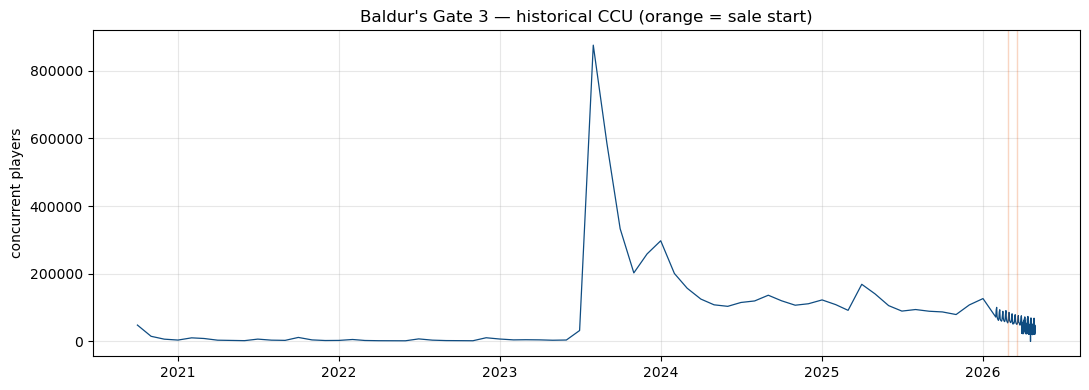

In [ ]:
ccu_df = pd.read_sql(
    'SELECT timestamp, player_count FROM steamcharts_history WHERE appid=? ORDER BY timestamp',
    conn, params=(APPID,),
)
ccu_df['timestamp'] = pd.to_datetime(ccu_df['timestamp'], utc=True)

if not ccu_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(ccu_df['timestamp'], ccu_df['player_count'], linewidth=0.9, color='#0f4c81')
    # Overlay sale events from the price-history table as vertical bands
    if not ph_df.empty:
        sales = ph_df[ph_df['cut'] > 0]
        for ts in sales['timestamp']:
            ax.axvline(ts, color='#ea580c', alpha=0.25, linewidth=1)
    ax.set_title(f'{GAME_NAME} — historical CCU (orange = sale start)')
    ax.set_ylabel('concurrent players')
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('no CCU history')

## Final summary

In [ ]:
rows = pd.read_sql(
    '''SELECT 'games'                AS table_name, COUNT(*) AS rows FROM games WHERE appid=?
       UNION ALL SELECT 'game_genres',         COUNT(*)   FROM game_genres        WHERE appid=?
       UNION ALL SELECT 'game_categories',     COUNT(*)   FROM game_categories    WHERE appid=?
       UNION ALL SELECT 'reviews_summary',     COUNT(*)   FROM reviews_summary    WHERE appid=?
       UNION ALL SELECT 'review_timestamps',   COUNT(*)   FROM review_timestamps  WHERE appid=?
       UNION ALL SELECT 'steamspy',            COUNT(*)   FROM steamspy           WHERE appid=?
       UNION ALL SELECT 'steamspy_tags',       COUNT(*)   FROM steamspy_tags      WHERE appid=?
       UNION ALL SELECT 'itad_mapping',        COUNT(*)   FROM itad_mapping       WHERE appid=?
       UNION ALL SELECT 'price_history',       COUNT(*)   FROM price_history      WHERE appid=?
       UNION ALL SELECT 'steamcharts_history', COUNT(*)   FROM steamcharts_history WHERE appid=?''',
    conn, params=[APPID]*10,
)
rows

,table_name,rows
0,games,1
1,game_genres,3
2,game_categories,23
3,reviews_summary,1
4,review_timestamps,0
5,steamspy,1
6,steamspy_tags,20
7,itad_mapping,1
8,price_history,5
9,steamcharts_history,844


In [ ]:
conn.close()